HOMEWORK 1

LUCA NICOLOSI 1000047978

In [3]:
import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf

In [4]:
# STEP 0

df = pd.read_csv('symbol_info_3-25.csv') # I'm importing the dataset

df_clean = df[(df['is_actively_trading'] == 1) & (df['is_etf'] == 0) & (df['is_fund'] == 0)] # I'm selecting only the active companies excluding those who invest in ETF and funds

df_sector = df_clean[df_clean['sector'] == 'Basic Materials'].copy() # I'm selecting the companies which belong to th Basic Materials industry


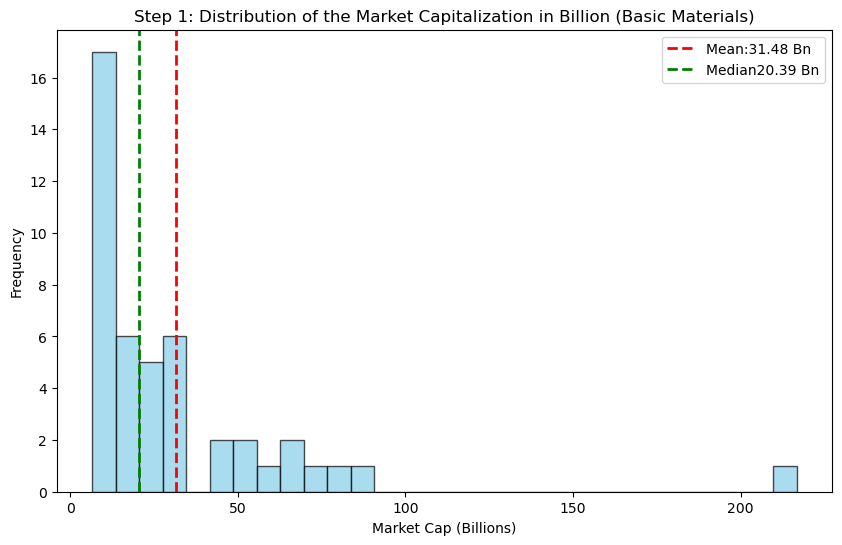

In [7]:
# STEP 1

df_sector['market_cap_b'] = df_sector['market_cap'] / 1e9 # I'm creating a new variable which includes the market_cap variable in billion

plt.figure(figsize=(10,6)) # here I'm setting the dimension of the plot. 10 indicates the width and 6 the height 

plt.hist(df_sector['market_cap_b'], bins= 30, color= 'skyblue', edgecolor= 'black', alpha = 0.7) # I'm creating the histogram based on df_sector. Bins = 30 means that the histogram is going to have 30 columns.

mean_market_cap = df_sector['market_cap_b'].mean() # I'm computing the mean of the market_cap variable
median_market_cap = df_sector['market_cap_b'].median() # I'm computing the median of the market_cap variable

plt.axvline(mean_market_cap, color = 'red', linestyle= 'dashed', linewidth = 2, label = f'Mean:{mean_market_cap:.2f} Bn') # I'm adding into the histogram a line which indicates the mean  of the market_cap variable.
plt.axvline(median_market_cap,color = 'green', linestyle = 'dashed', linewidth = 2, label = f'Median{median_market_cap:.2f} Bn' ) # I'm addinto into the hostogram a line which indicates the median of the market_cap variable.

plt.title('Step 1: Distribution of the Market Capitalization in Billion (Basic Materials)') # I'm adding the title of the plot
plt.xlabel('Market Cap (Billions)') # I'm adding a label for the x axis 
plt.ylabel('Frequency') # I'm adding a label for the y axis 
plt.legend() # I'm adding a legend
plt.show()


            







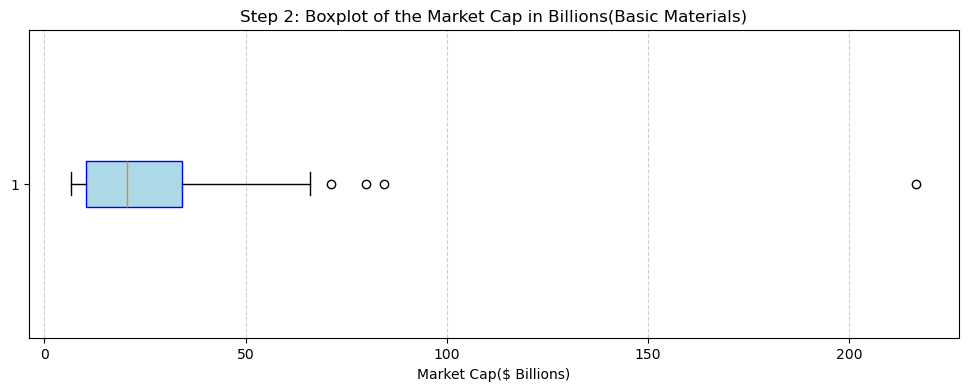

In [ ]:
# STEP 2

plt.figure(figsize=(12,4))

plt.boxplot(df_sector['market_cap_b'], vert= False, patch_artist= True, boxprops=dict(facecolor= 'lightblue', color = 'blue')) # now I'm creating the boxplot. With vert = False the boxplot is going to be horizontal. Patch_artist = True allows me to specify the color inside the box. Finally with boxprops I'm defining the properties of the box.

plt.title('Step 2: Boxplot of the Market Cap in Billions(Basic Materials)')
plt.xlabel('Market Cap($ Billions)')
plt.grid(axis= 'x', linestyle= '--', alpha = 0.6)
plt.show()

Q1 = df_sector['market_cap_b'].quantile(0.25)
Q3 = df_sector['market_cap_b'].quantile(0.75)
IQR = Q3 - Q1

limit = Q3 + 1.5 * IQR # since the distribution of the market_cap variable is right skewned, the outliers are concentred on the right side of the plot. This means that the outliers are represented by companies with an extremely high market capitalization.
df_filtered = df_sector[df_sector['market_cap_b'] <= limit].copy() # now I'm filtering the data frame by considering all the companies with a market capitalization which is below than or equal to the limit.




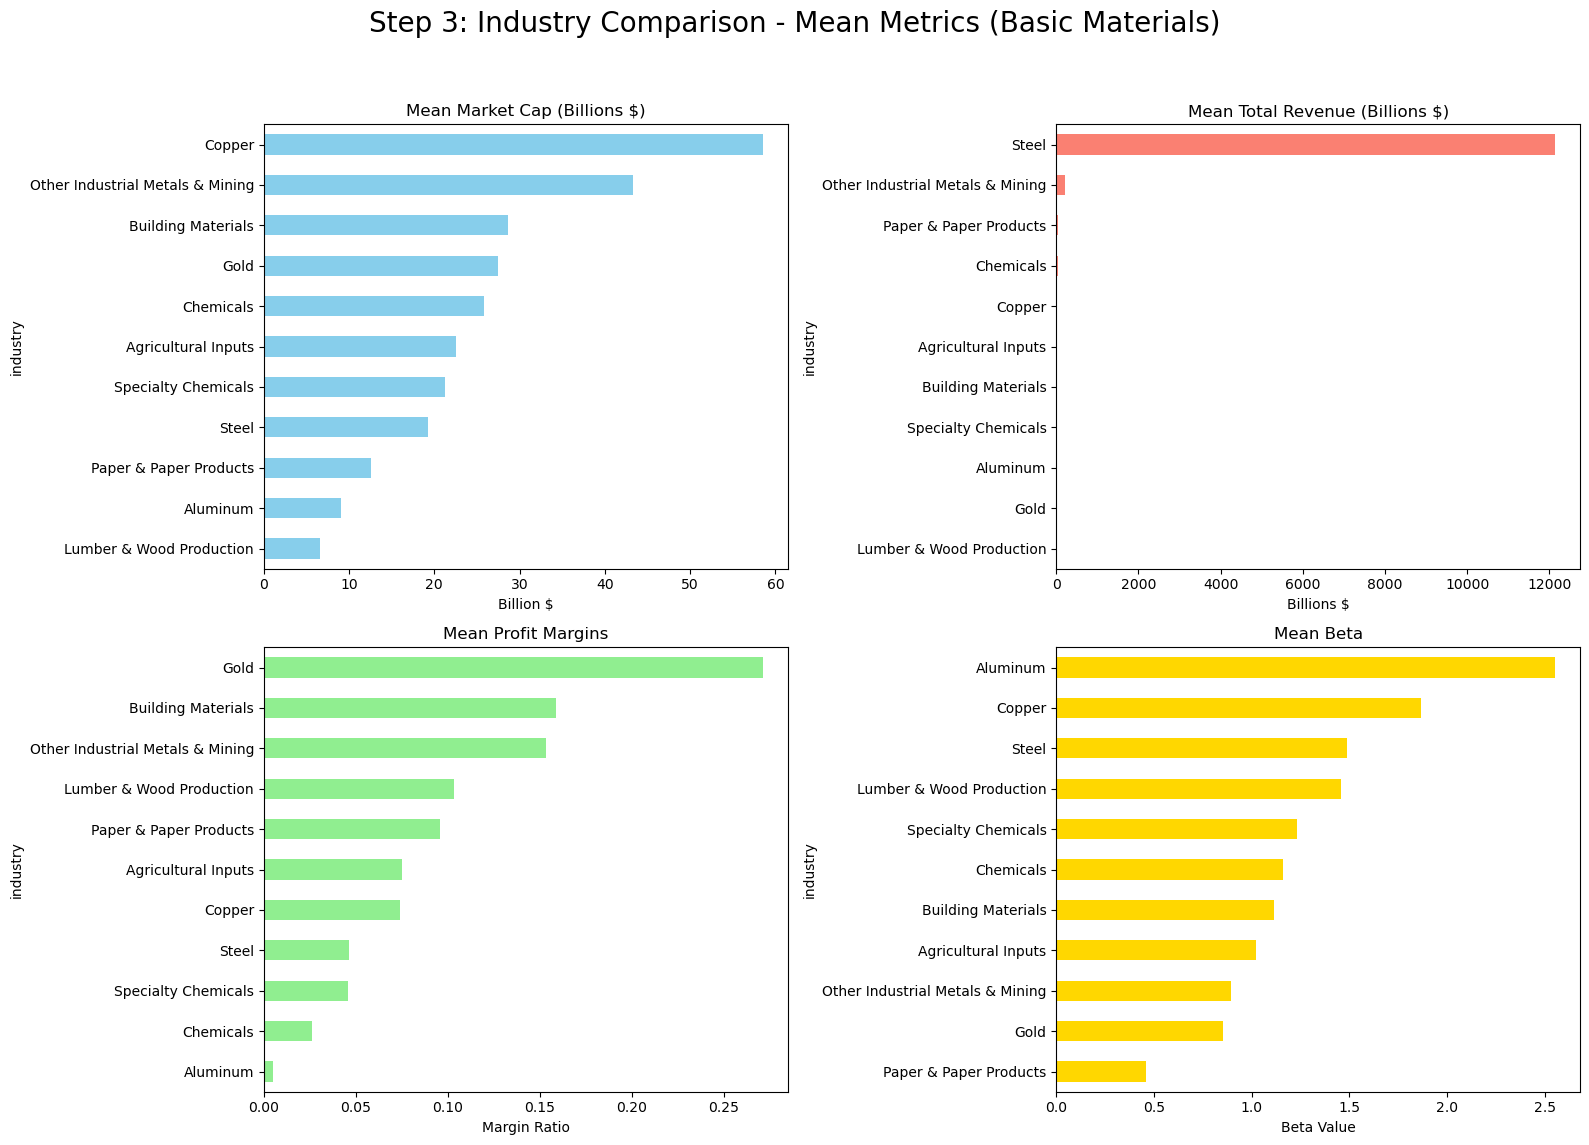

In [ ]:
# STEP 3

df_filtered['total_revenue_b'] = df_filtered['total_revenue'] / 1e9

industry_comparison = df_filtered.groupby('industry')[['market_cap_b', 'total_revenue_b', 'profit_margins', 'beta']].mean() # By using groupby, I'm computing the mean of those variables by considering only the industries.

fig,axes = plt.subplots(2,2, figsize = (16,12))
fig.suptitle('Step 3: Industry Comparison - Mean Metrics (Basic Materials)', fontsize = 20) # I'm setting the title of the overall plot

# Graph 1 
industry_comparison['market_cap_b'].sort_values().plot(kind = 'barh', ax = axes[0,0], color = 'skyblue') # I'm creating an horizontal bar chart considering the ordered values of the market capitalization espressed in billions
axes[0,0].set_title('Mean Market Cap (Billions $)') 
axes[0,0].set_xlabel('Billion $')

#  Graph 2 
industry_comparison['total_revenue_b'].sort_values().plot(kind= 'barh', ax = axes[0,1],color = 'salmon') # I'm creating an horizontal bar chart considering the ordered values of the total revenue espressed in billions
axes[0,1].set_title('Mean Total Revenue (Billions $)')
axes[0,1].set_xlabel('Billions $')

# Graph 3 
industry_comparison['profit_margins'].sort_values().plot(kind= 'barh', ax = axes[1,0], color = 'lightgreen') # I'm creating an horizontal bar chart considering the ordered values of the profit margins
axes[1,0].set_title('Mean Profit Margins')
axes[1,0].set_xlabel('Margin Ratio')

# Graph 4
industry_comparison['beta'].sort_values().plot(kind= 'barh', ax = axes[1,1], color='gold') # I'm creating an horizontal bar chart considering the ordered values of the beta variable.
axes[1,1].set_title('Mean Beta')
axes[1,1].set_xlabel('Beta Value')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Allow me to adjust the subplots layout to prevent overlapping and leave space for the main title
plt.show()










<Figure size 1200x800 with 0 Axes>

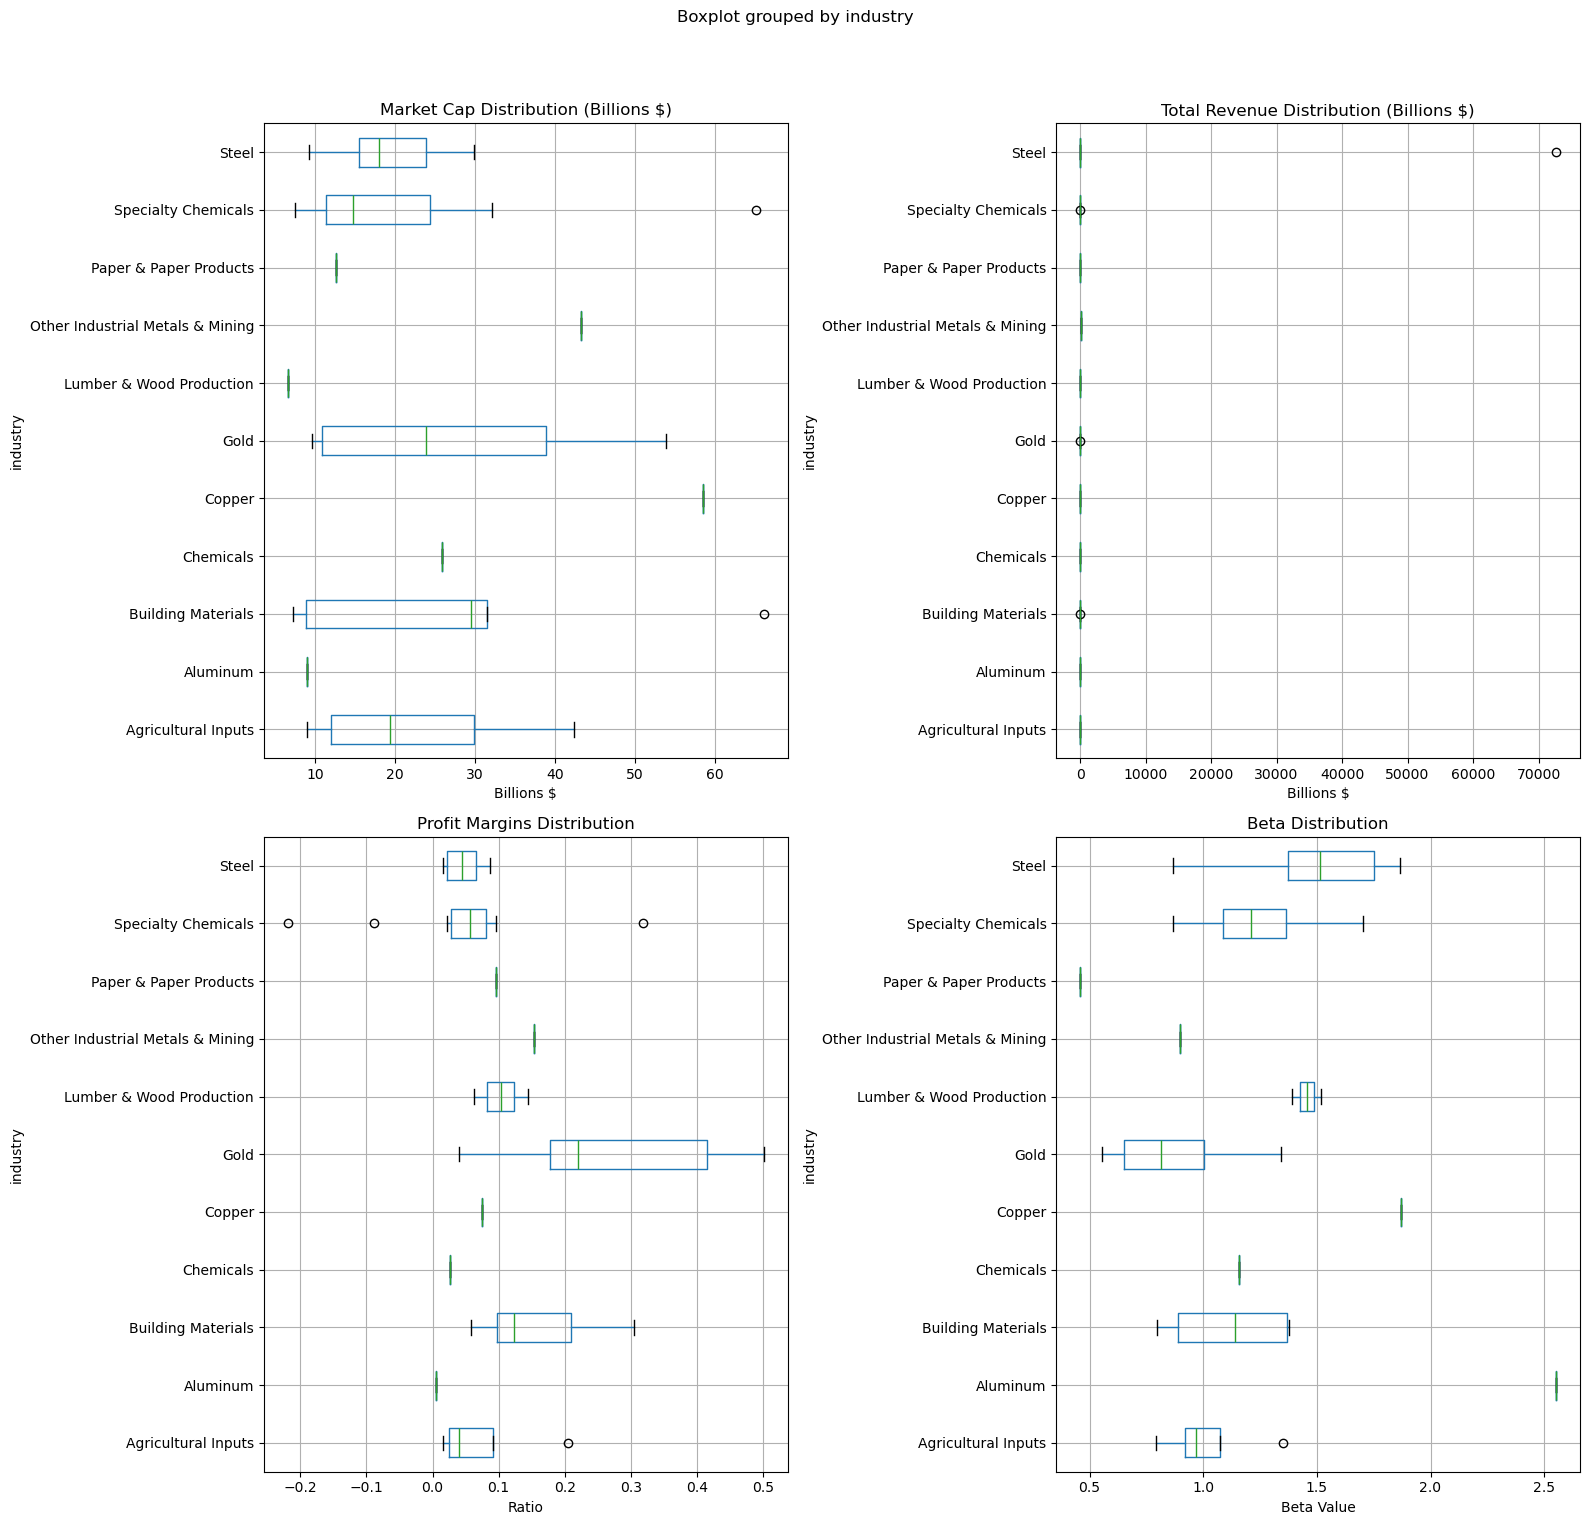

In [ ]:
# STEP 4

fig, axes = plt.subplots(2,2, figsize= (16,16))
fig.suptitle('Step 4: Industry Dispersion Analysis (Basic Materials)', fontsize = 20)

# Graph 1
df_filtered.boxplot(column= 'market_cap_b', by = 'industry', ax = axes[0,0], vert = False) # I'm creating a boxplot which shows the dispersion of the market_cap variable espressed in billions in each industry.
axes[0,0].set_title('Market Cap Distribution (Billions $)')
axes[0,0].set_xlabel('Billions $')

# Graph 2
df_filtered.boxplot(column='total_revenue_b', by = 'industry', ax= axes[0,1], vert = False) # I'm creating a boxplot which shows the dispersion of the total revenue variable espressed in billions in each industry.
axes[0,1].set_title('Total Revenue Distribution (Billions $)')
axes[0,1].set_xlabel('Billions $')

# Graph 3
df_filtered.boxplot(column= 'profit_margins', by = 'industry', ax = axes[1,0], vert = False ) # I'm creating a boxplot which shows the dispersion of the profit margins variable in each industry.
axes[1,0].set_title('Profit Margins Distribution')
axes[1,0].set_xlabel('Ratio')

df_filtered.boxplot(column= 'beta', by = 'industry', ax = axes[1,1], vert = False) # I'm creating a boxplot which shows the dispersion of the beta variable in each industry.
axes[1,1].set_title('Beta Distribution')
axes[1,1].set_xlabel('Beta Value')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()